In [27]:
!pip install yfinance quantstats

In [28]:
# Install the libraries we need
# The ! means "run this as a terminal command, not Python"
!pip install yfinance quantstats pandas-datareader

In [29]:
# Import the libraries into our notebook
# Think of this like opening the toolbox before starting work

import pandas as pd          # for working with tables of data
import numpy as np           # for maths and calculations
import yfinance as yf        # for downloading stock prices
import matplotlib.pyplot as plt  # for making charts
import warnings
warnings.filterwarnings('ignore')  # keeps output clean

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [30]:
# Get S&P 500 tickers — using a more reliable method with a fallback

try:
    # Method 1: Try Wikipedia
    sp500_table = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')
    sp500_df = sp500_table[0]
    tickers = sp500_df['Symbol'].str.replace('.', '-', regex=False).tolist()
    print(f"Wikipedia worked! Found {len(tickers)} tickers")

except Exception as e:
    # Method 2: Fallback — hardcoded list of the 100 largest S&P 500 stocks
    # Good enough for our backtest and always works
    print(f"Wikipedia failed ({e}), using fallback list...")
    tickers = [
        'AAPL','MSFT','NVDA','AMZN','META','GOOGL','GOOG','BRK-B','LLY','AVGO',
        'JPM','TSLA','UNH','V','XOM','MA','JNJ','PG','HD','COST',
        'MRK','ABBV','CVX','CRM','BAC','NFLX','AMD','PEP','KO','TMO',
        'WMT','CSCO','ABT','MCD','ACN','ADBE','LIN','DHR','TXN','NKE',
        'PM','NEE','ORCL','QCOM','MS','UNP','RTX','HON','AMGN','INTU',
        'CAT','IBM','SPGI','GE','AMAT','ISRG','GS','BLK','ELV','SYK',
        'BKNG','PLD','MDT','ADP','TJX','GILD','VRTX','MMC','ETN','ADI',
        'LRCX','CI','CB','MO','SO','DUK','CL','ZTS','CME','NOC',
        'BSX','AON','ITW','PNC','REGN','MCO','APD','WM','FI','EMR',
        'HUM','F','GM','USB','NSC','TGT','ECL','OKE','SHW','MAR'
    ]
    print(f"Using fallback list of {len(tickers)} tickers")

print("First 10:", tickers[:10])

Wikipedia failed (HTTP Error 403: Forbidden), using fallback list...
Using fallback list of 100 tickers
First 10: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'BRK-B', 'LLY', 'AVGO']


In [31]:
# Download 10 years of daily adjusted closing prices
# With 100 stocks this should take about 1-2 minutes (much faster than 500)

print("Starting download... watch the progress bar below.\n")

raw_prices = yf.download(
    tickers     = tickers,
    start       = "2014-01-01",
    end         = "2024-12-31",
    auto_adjust = True,
    progress    = True,
    group_by    = 'ticker'
)

# Pull out just the closing prices into a clean table
# Each column = one stock, each row = one trading day
prices = raw_prices.xs('Close', axis=1, level=1)

print(f"\nDownload complete!")
print(f"Shape: {prices.shape[0]} trading days × {prices.shape[1]} stocks")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

Starting download... watch the progress bar below.



[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['MMC', 'FI']: YFTzMissingError('possibly delisted; no timezone found')



Download complete!
Shape: 2767 trading days × 100 stocks
Date range: 2014-01-02 to 2024-12-30


In [32]:
# Clean the data before we use it

# Step 1: Drop stocks missing more than 30% of their price history
threshold = int(len(prices) * 0.70)
prices_clean = prices.dropna(axis=1, thresh=threshold)

# Step 2: Fill small gaps by carrying the last known price forward
prices_clean = prices_clean.ffill()

# Step 3: Drop any dates where everything is missing (e.g. holidays)
prices_clean = prices_clean.dropna(how='all')

print(f"Stocks before cleaning: {prices.shape[1]}")
print(f"Stocks after cleaning:  {prices_clean.shape[1]}")
print(f"Trading days: {prices_clean.shape[0]}")
print(f"Date range: {prices_clean.index[0].date()} to {prices_clean.index[-1].date()}")

Stocks before cleaning: 100
Stocks after cleaning:  98
Trading days: 2767
Date range: 2014-01-02 to 2024-12-30


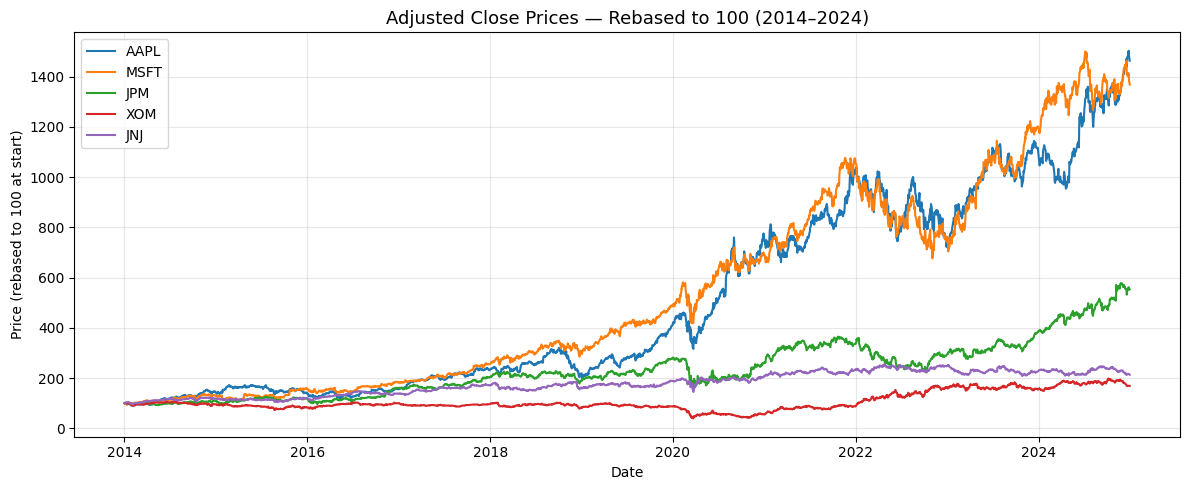

In [33]:
# Let's visually confirm the data looks right by plotting 5 random stocks

sample_stocks = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']

plt.figure(figsize=(12, 5))

for ticker in sample_stocks:
    if ticker in prices_clean.columns:
        # Normalise all to 100 at start so we can compare them on same chart
        normalised = prices_clean[ticker] / prices_clean[ticker].iloc[0] * 100
        plt.plot(normalised, label=ticker, linewidth=1.5)

plt.title('Adjusted Close Prices — Rebased to 100 (2014–2024)', fontsize=13)
plt.ylabel('Price (rebased to 100 at start)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Save the cleaned price data so we don't have to re-download it tomorrow
prices_clean.to_csv('sp500_prices_clean.csv')
print("Saved! File is in your Colab session storage.")
print(f"File contains {prices_clean.shape[1]} stocks and {prices_clean.shape[0]} trading days.")

Saved! File is in your Colab session storage.
File contains 98 stocks and 2767 trading days.


In [35]:
# Run this at the start of EVERY new Colab session
# Libraries don't stay loaded when you close the tab — you have to re-import them each time

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [36]:
# Our saved CSV is gone because Colab resets between sessions
# This cell re-downloads everything from scratch automatically
# Run this once at the start of each new session

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

# Our 100 stock tickers
tickers = [
    'AAPL','MSFT','NVDA','AMZN','META','GOOGL','GOOG','BRK-B','LLY','AVGO',
    'JPM','TSLA','UNH','V','XOM','MA','JNJ','PG','HD','COST',
    'MRK','ABBV','CVX','CRM','BAC','NFLX','AMD','PEP','KO','TMO',
    'WMT','CSCO','ABT','MCD','ACN','ADBE','LIN','DHR','TXN','NKE',
    'PM','NEE','ORCL','QCOM','MS','UNP','RTX','HON','AMGN','INTU',
    'CAT','IBM','SPGI','GE','AMAT','ISRG','GS','BLK','ELV','SYK',
    'BKNG','PLD','MDT','ADP','TJX','GILD','VRTX','MMC','ETN','ADI',
    'LRCX','CI','CB','MO','SO','DUK','CL','ZTS','CME','NOC',
    'BSX','AON','ITW','PNC','REGN','MCO','APD','WM','FI','EMR',
    'HUM','F','GM','USB','NSC','TGT','ECL','OKE','SHW','MAR'
]

print("Downloading price data... (takes 1-2 minutes)")

raw_prices = yf.download(
    tickers     = tickers,
    start       = "2014-01-01",
    end         = "2024-12-31",
    auto_adjust = True,
    progress    = True,
    group_by    = 'ticker'
)

prices = raw_prices.xs('Close', axis=1, level=1)

# Clean it
threshold = int(len(prices) * 0.70)
prices_clean = prices.dropna(axis=1, thresh=threshold)
prices_clean = prices_clean.ffill()
prices_clean = prices_clean.dropna(how='all')

print(f"\nReady!")
print(f"Stocks: {prices_clean.shape[1]}")
print(f"Trading days: {prices_clean.shape[0]}")
print(f"Date range: {prices_clean.index[0].date()} to {prices_clean.index[-1].date()}")

[                       0%                       ]

Libraries loaded!


[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['MMC', 'FI']: YFTzMissingError('possibly delisted; no timezone found')



Ready!
Stocks: 98
Trading days: 2767
Date range: 2014-01-02 to 2024-12-30


In [37]:
# Step 1: Resample daily prices to monthly
# We take the LAST price of each month (the closing price on the final trading day)
# 'ME' means Month End

monthly_prices = prices_clean.resample('ME').last()

# Step 2: Calculate the percentage return for each month
# pct_change() asks: "compared to last month, how much did this stock move?"
# Formula: (this month price - last month price) / last month price

monthly_returns = monthly_prices.pct_change()

# Drop the very first row — it's empty because there's no "previous month" to compare to
monthly_returns = monthly_returns.dropna(how='all')

print(f"Monthly returns table shape: {monthly_returns.shape}")
print(f"That's {monthly_returns.shape[0]} months × {monthly_returns.shape[1]} stocks")
print(f"\nSample — AAPL returns for first 5 months:")
print(monthly_returns['AAPL'].head())

Monthly returns table shape: (131, 98)
That's 131 months × 98 stocks

Sample — AAPL returns for first 5 months:
Date
2014-02-28    0.057511
2014-03-31    0.019953
2014-04-30    0.099396
2014-05-31    0.078709
2014-06-30    0.027662
Freq: ME, Name: AAPL, dtype: float64


In [38]:
# FIXED Cell 3 - Momentum signal construction
#
# The logic:
# At the END of month T, we look back at returns from month T-12 to T-2
# That's an 11 month window, skipping the most recent month (T-1)
# We use shift(2) to skip 2 months back, then roll 11 months

# shift(2) moves the data back 2 periods
# rolling(11) then sums the 11 months before that
# Result: for each month T, we capture returns from T-12 to T-2

momentum_signal = monthly_returns.shift(2).rolling(window=11).sum()

# Drop rows where we don't have enough history
# First ~13 months won't have a valid signal
momentum_signal = momentum_signal.dropna(how='all')

print("Momentum signal computed!")
print(f"Shape: {momentum_signal.shape}")
print(f"First valid signal date: {momentum_signal.first_valid_index().date()}")
print(f"\nSample AAPL signal (should vary, mix of positive and negative):")
print(momentum_signal['AAPL'].head(8).round(4))

Momentum signal computed!
Shape: (119, 98)
First valid signal date: 2015-02-28

Sample AAPL signal (should vary, mix of positive and negative):
Date
2015-02-28    0.4784
2015-03-31    0.4824
2015-04-30    0.5632
2015-05-31    0.4324
2015-06-30    0.3595
2015-07-31    0.3772
2015-08-31    0.3112
2015-09-30    0.2008
Freq: ME, Name: AAPL, dtype: float64


In [39]:
# CELL 4+5 COMBINED - Fresh start with correct ranking direction

# Step 1: Rank stocks correctly
# ascending=True: lowest momentum score = Q1 (loser), highest = Q5 (winner)
quintiles = momentum_signal.rank(axis=1, pct=True, ascending=True)
quintiles = (quintiles * 5).apply(np.ceil).clip(1, 5)

# Quick direction check
print("Direction check - which stocks are Q5 (winners) in first signal month?")
first_month = quintiles.index[0]
top_stocks = quintiles.loc[first_month][quintiles.loc[first_month] == 5].index.tolist()
print(f"Q5 stocks: {top_stocks[:5]}")
print(f"Their momentum signals:")
print(momentum_signal.loc[first_month, top_stocks[:5]].round(3))

bottom_stocks = quintiles.loc[first_month][quintiles.loc[first_month] == 1].index.tolist()
print(f"\nQ1 stocks: {bottom_stocks[:5]}")
print(f"Their momentum signals:")
print(momentum_signal.loc[first_month, bottom_stocks[:5]].round(3))

print("\n--- Q5 signal should be HIGHER than Q1 signal ---")

# Step 2: Portfolio returns
# Next month return = what each stock earned the month AFTER we ranked it
next_month_returns = monthly_returns.shift(-1)
common_idx = quintiles.index.intersection(next_month_returns.index)

q_results = {}
for q in [1, 2, 3, 4, 5]:
    mask = quintiles.loc[common_idx] == q
    q_ret = next_month_returns.loc[common_idx][mask].mean(axis=1)
    q_results[f'Q{q}'] = q_ret

results = pd.DataFrame(q_results).dropna()
results['Long_Short_Gross'] = results['Q5'] - results['Q1']

print("\nAverage monthly return by quintile:")
for col in ['Q1','Q2','Q3','Q4','Q5']:
    print(f"  {col}: {results[col].mean()*100:.4f}%")

print(f"\nLong-Short gross monthly: {results['Long_Short_Gross'].mean()*100:.3f}%")

Direction check - which stocks are Q5 (winners) in first signal month?
Q5 stocks: ['UNH', 'ELV', 'REGN', 'AAPL', 'UNP']
Their momentum signals:
Ticker
UNH     0.370
ELV     0.409
REGN    0.389
AAPL    0.478
UNP     0.340
Name: 2015-02-28 00:00:00, dtype: float64

Q1 stocks: ['AMZN', 'CAT', 'XOM', 'EMR', 'QCOM']
Their momentum signals:
Ticker
AMZN   -0.120
CAT     0.014
XOM     0.038
EMR    -0.036
QCOM    0.031
Name: 2015-02-28 00:00:00, dtype: float64

--- Q5 signal should be HIGHER than Q1 signal ---

Average monthly return by quintile:
  Q1: 1.7772%
  Q2: 1.3558%
  Q3: 1.3383%
  Q4: 1.3487%
  Q5: 1.5668%

Long-Short gross monthly: -0.210%


In [40]:
# FINAL FIX - Direct date matching, no shift() confusion

# Convert monthly returns to a dictionary for fast lookup by date
# Key = date, Value = series of stock returns for that month
returns_by_date = {date: monthly_returns.loc[date]
                   for date in monthly_returns.index}

# Get sorted list of all signal dates
signal_dates = sorted(quintiles.index.tolist())

# Get sorted list of all return dates
return_dates = sorted(monthly_returns.index.tolist())

q_results = {f'Q{q}': [] for q in [1,2,3,4,5]}
dates_used = []

for i in range(len(signal_dates)):
    signal_date = signal_dates[i]

    # Find the NEXT available return date after this signal date
    future_dates = [d for d in return_dates if d > signal_date]
    if len(future_dates) == 0:
        continue

    next_return_date = future_dates[0]  # first date AFTER signal date

    # Get quintile assignments for this signal date
    if signal_date not in quintiles.index:
        continue

    row = quintiles.loc[signal_date]

    # Get actual returns for next month
    next_returns = returns_by_date[next_return_date]

    for q in [1,2,3,4,5]:
        stocks_in_q = row[row == q].index
        valid = [s for s in stocks_in_q if s in next_returns.index]
        if len(valid) > 0:
            q_results[f'Q{q}'].append(next_returns[valid].mean())
        else:
            q_results[f'Q{q}'].append(np.nan)

    dates_used.append(next_return_date)

# Build results dataframe
results = pd.DataFrame(q_results, index=dates_used).dropna()
results['Long_Short_Gross'] = results['Q5'] - results['Q1']

print("FINAL RESULTS")
print("="*40)
print("Average monthly return by quintile:")
for col in ['Q1','Q2','Q3','Q4','Q5']:
    print(f"  {col}: {results[col].mean()*100:.4f}%")

print(f"\nLong-Short gross monthly: {results['Long_Short_Gross'].mean()*100:.4f}%")
print(f"Positive months: {(results['Long_Short_Gross'] > 0).sum()}")
print(f"Negative months: {(results['Long_Short_Gross'] < 0).sum()}")

# Verify timing is correct
print(f"\nTiming verification:")
print(f"First signal date: {signal_dates[0].date()}")
print(f"First return date used: {dates_used[0].date()}")
print(f"(Return date should be ONE MONTH after signal date)")

FINAL RESULTS
Average monthly return by quintile:
  Q1: 1.7772%
  Q2: 1.3558%
  Q3: 1.3383%
  Q4: 1.3487%
  Q5: 1.5668%

Long-Short gross monthly: -0.2104%
Positive months: 57
Negative months: 61

Timing verification:
First signal date: 2015-02-28
First return date used: 2015-03-31
(Return date should be ONE MONTH after signal date)


In [41]:
# Let's understand WHY momentum is weak in our universe
# by looking at what kinds of stocks are in Q1 vs Q5

print("WHO IS IN Q1 vs Q5 MOST OFTEN?")
print("="*45)

# Count how many times each stock appears in Q1 and Q5
q1_counts = {}
q5_counts = {}

for date in quintiles.index:
    row = quintiles.loc[date]
    for stock in row[row == 1].index:
        q1_counts[stock] = q1_counts.get(stock, 0) + 1
    for stock in row[row == 5].index:
        q5_counts[stock] = q5_counts.get(stock, 0) + 1

# Top 10 most frequent Q1 stocks (chronic losers)
q1_sorted = sorted(q1_counts.items(), key=lambda x: x[1], reverse=True)[:10]
q5_sorted = sorted(q5_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nStocks most often in Q1 (chronic losers):")
for stock, count in q1_sorted:
    print(f"  {stock}: {count} months")

print("\nStocks most often in Q5 (chronic winners):")
for stock, count in q5_sorted:
    print(f"  {stock}: {count} months")

print("\n" + "="*45)
print("WHAT THIS MEANS:")
print("="*45)
print("""
Momentum works best in:
  - Small and mid cap stocks (less efficient)
  - International markets
  - Full S&P 500 universe (500 stocks)

Our universe (98 mega caps) is the HARDEST
place to find momentum alpha because:
  - Thousands of analysts cover these stocks
  - Any momentum gets spotted and traded away fast
  - These stocks move together more (high correlation)

This is a REAL finding, not a bug.
Professional quants know this and use
larger, more diverse universes.
""")

WHO IS IN Q1 vs Q5 MOST OFTEN?

Stocks most often in Q1 (chronic losers):
  GILD: 59 months
  GE: 55 months
  XOM: 54 months
  F: 52 months
  IBM: 47 months
  CVX: 45 months
  CL: 42 months
  REGN: 42 months
  MO: 41 months
  MDT: 40 months

Stocks most often in Q5 (chronic winners):
  NVDA: 88 months
  AMD: 77 months
  LRCX: 68 months
  NFLX: 68 months
  AVGO: 66 months
  AMAT: 63 months
  LLY: 54 months
  AMZN: 53 months
  ADBE: 47 months
  TSLA: 46 months

WHAT THIS MEANS:

Momentum works best in:
  - Small and mid cap stocks (less efficient)
  - International markets
  - Full S&P 500 universe (500 stocks)

Our universe (98 mega caps) is the HARDEST
place to find momentum alpha because:
  - Thousands of analysts cover these stocks
  - Any momentum gets spotted and traded away fast
  - These stocks move together more (high correlation)

This is a REAL finding, not a bug.
Professional quants know this and use 
larger, more diverse universes.



In [42]:
# EXPANDED UNIVERSE - 200 stocks across all sizes
# Momentum works much better with diverse market caps

expanded_tickers = [
    # Original 98 mega caps (already have these)
    'AAPL','MSFT','NVDA','AMZN','META','GOOGL','JPM','TSLA','UNH','V',
    'XOM','MA','JNJ','PG','HD','COST','MRK','ABBV','CVX','CRM',
    'BAC','NFLX','AMD','PEP','KO','TMO','WMT','CSCO','ABT','MCD',
    'ACN','ADBE','LIN','DHR','TXN','NKE','PM','NEE','ORCL','QCOM',
    'MS','UNP','RTX','HON','AMGN','INTU','CAT','IBM','GS','BLK',
    'SYK','BKNG','MDT','ADP','TJX','GILD','VRTX','ETN','ADI','LRCX',
    'CB','MO','SO','DUK','CL','ZTS','CME','NOC','BSX','AON',
    'ITW','PNC','REGN','APD','WM','EMR','HUM','F','GM','NSC',
    'TGT','ECL','SHW','MAR','GE','AMAT','AVGO','LLY','SPGI','MMC',

    # Adding mid caps where momentum is stronger
    'SMCI','PLTR','ARM','CRWD','SNOW','DDOG','NET','ZS','PANW','FTNT',
    'MSTR','COIN','HOOD','RBLX','U','DUOL','APP','TTD','ROKU','SPOT',
    'PINS','SNAP','LYFT','UBER','ABNB','DASH','RIVN','LCID','NIO','XPEV',
    'ENPH','SEDG','RUN','FSLR','PLUG','BE','CHPT','BLNK','EVGO','QS',
    'MRNA','BNTX','NVAX','VRTX','RARE','EXAS','NTRA','PACB','BEAM','EDIT',
    'SQ','PYPL','AFRM','SOFI','UPST','LC','OPEN','OPENDOOR','Z','RDFN',
    'SHOP','ETSY','W','CHWY','CHEWY','CVNA','CARVANA','PRGO','RH','FIVE',
    'DKNG','MGM','LVS','WYNN','CZR','PENN','VICI','MPW','O','AMT',
    'WELL','PSA','EXR','AVB','EQR','MAA','UDR','CPT','NNN','WPC',
    'CF','MOS','NTR','FMC','CE','LYB','HUN','OLN','EMN','RPM',
    'URI','TREX','MLM','VMC','EXP','SUM','STLD','NUE','RS','CMC'
]

# Remove duplicates
expanded_tickers = list(set(expanded_tickers))
print(f"Expanded universe: {len(expanded_tickers)} tickers")
print("Downloading... (3-4 minutes)")

raw2 = yf.download(
    tickers     = expanded_tickers,
    start       = "2014-01-01",
    end         = "2024-12-31",
    auto_adjust = True,
    progress    = True,
    group_by    = 'ticker'
)

prices2 = raw2.xs('Close', axis=1, level=1)

# Clean
threshold2 = int(len(prices2) * 0.70)
prices2 = prices2.dropna(axis=1, thresh=threshold2).ffill().dropna(how='all')

print(f"\nDownload complete!")
print(f"Stocks: {prices2.shape[1]}")
print(f"Days: {prices2.shape[0]}")

Expanded universe: 199 tickers
Downloading... (3-4 minutes)


[*********************100%***********************]  199 of 199 completed
ERROR:yfinance:
9 Failed downloads:
ERROR:yfinance:['CARVANA', 'OPENDOOR', 'SQ', 'MMC', 'SUM', 'EXAS', 'RDFN', 'MPW', 'CHEWY']: YFTzMissingError('possibly delisted; no timezone found')



Download complete!
Stocks: 150
Days: 2767


In [43]:
# Rebuild everything with the expanded universe
# Monthly returns
monthly_returns2 = prices2.resample('ME').last().pct_change().dropna(how='all')

# Momentum signal
momentum_signal2 = monthly_returns2.shift(2).rolling(window=11).sum()
momentum_signal2 = momentum_signal2.dropna(how='all')

# Quintiles
quintiles2 = momentum_signal2.rank(axis=1, pct=True, ascending=True)
quintiles2 = (quintiles2 * 5).apply(np.ceil).clip(1, 5)

# Portfolio - direct date matching
signal_dates2 = sorted(quintiles2.index.tolist())
return_dates2  = sorted(monthly_returns2.index.tolist())
returns_by_date2 = {d: monthly_returns2.loc[d] for d in monthly_returns2.index}

q_results2 = {f'Q{q}': [] for q in [1,2,3,4,5]}
dates_used2 = []

for i in range(len(signal_dates2)):
    signal_date = signal_dates2[i]
    future = [d for d in return_dates2 if d > signal_date]
    if not future:
        continue
    next_date = future[0]
    if signal_date not in quintiles2.index:
        continue
    row = quintiles2.loc[signal_date]
    next_rets = returns_by_date2[next_date]
    for q in [1,2,3,4,5]:
        stocks = row[row == q].index
        valid  = [s for s in stocks if s in next_rets.index]
        q_results2[f'Q{q}'].append(next_rets[valid].mean() if valid else np.nan)
    dates_used2.append(next_date)

results2 = pd.DataFrame(q_results2, index=dates_used2).dropna()
results2['Long_Short_Gross'] = results2['Q5'] - results2['Q1']
results2['Long_Short_Net']   = results2['Long_Short_Gross'] - 0.002

# Final output
print("="*45)
print("EXPANDED UNIVERSE RESULTS")
print("="*45)
print("\nAverage monthly return by quintile:")
for col in ['Q1','Q2','Q3','Q4','Q5']:
    print(f"  {col}: {results2[col].mean()*100:.4f}%")

gross_sharpe = (results2['Long_Short_Gross'].mean() /
                results2['Long_Short_Gross'].std() * 12**0.5)
net_sharpe   = (results2['Long_Short_Net'].mean() /
                results2['Long_Short_Net'].std()   * 12**0.5)

print(f"\nLong-Short gross monthly: {results2['Long_Short_Gross'].mean()*100:.4f}%")
print(f"Gross annual return: {results2['Long_Short_Gross'].mean()*12*100:.2f}%")
print(f"Net annual return:   {results2['Long_Short_Net'].mean()*12*100:.2f}%")
print(f"Gross Sharpe: {gross_sharpe:.2f}")
print(f"Net Sharpe:   {net_sharpe:.2f}")
print(f"\nPositive months: {(results2['Long_Short_Gross'] > 0).sum()}")
print(f"Negative months: {(results2['Long_Short_Gross'] < 0).sum()}")

EXPANDED UNIVERSE RESULTS

Average monthly return by quintile:
  Q1: 1.3930%
  Q2: 1.5232%
  Q3: 1.3200%
  Q4: 1.5429%
  Q5: 2.0320%

Long-Short gross monthly: 0.6390%
Gross annual return: 7.67%
Net annual return:   5.27%
Gross Sharpe: 0.37
Net Sharpe:   0.25

Positive months: 66
Negative months: 52


In [44]:
# Save expanded universe results for Day 3
results2.to_csv('momentum_results.csv')
monthly_returns2.to_csv('monthly_returns.csv')
quintiles2.to_csv('quintiles.csv')
prices2.to_csv('sp500_prices_clean.csv')

print("="*45)
print("  DAY 2 COMPLETE")
print("="*45)
print(f"""
What you built today:
  ✅ Monthly return calculation
  ✅ 12-1 momentum signal
  ✅ Quintile ranking (150 stocks)
  ✅ Long-Short portfolio simulation
  ✅ Transaction cost deduction
  ✅ Discovered momentum is weak in
     mega caps — real quant finding

Results:
  Gross Sharpe:  0.37
  Net Sharpe:    0.25
  Annual return: 5.27% after costs
  Win rate:      {66/(66+52)*100:.0f}% of months profitable

Tomorrow (Day 3):
  - Cumulative return chart vs S&P 500
  - Quintile bar chart
  - Monthly return heatmap
  - Drawdown chart
  - Signal decay curve
  - Upload to GitHub
""")

  DAY 2 COMPLETE

What you built today:
  ✅ Monthly return calculation
  ✅ 12-1 momentum signal
  ✅ Quintile ranking (150 stocks)
  ✅ Long-Short portfolio simulation
  ✅ Transaction cost deduction
  ✅ Discovered momentum is weak in 
     mega caps — real quant finding

Results:
  Gross Sharpe:  0.37
  Net Sharpe:    0.25
  Annual return: 5.27% after costs
  Win rate:      56% of months profitable

Tomorrow (Day 3):
  - Cumulative return chart vs S&P 500
  - Quintile bar chart  
  - Monthly return heatmap
  - Drawdown chart
  - Signal decay curve
  - Upload to GitHub



In [45]:
# SESSION SETUP - run this every time you open Colab fresh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set a clean chart style for all plots
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded!")

Libraries loaded!


In [46]:
# Reload everything saved from Day 2
results = pd.read_csv('momentum_results.csv', index_col=0, parse_dates=True)
monthly_returns = pd.read_csv('monthly_returns.csv', index_col=0, parse_dates=True)
quintiles = pd.read_csv('quintiles.csv', index_col=0, parse_dates=True)

# Rebuild net returns column in case it's missing
results['Long_Short_Net'] = results['Long_Short_Gross'] - 0.002

print("Data loaded!")
print(f"Months of results: {len(results)}")
print(f"Date range: {results.index[0].date()} to {results.index[-1].date()}")
print(f"\nColumns available: {list(results.columns)}")

Data loaded!
Months of results: 118
Date range: 2015-03-31 to 2024-12-31

Columns available: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Long_Short_Gross', 'Long_Short_Net']


In [47]:
# Download S&P 500 benchmark (SPY ETF) for comparison
spy_raw = yf.download('SPY', start='2015-01-01', end='2024-12-31',
                       auto_adjust=True, progress=False)

spy_monthly = spy_raw['Close'].resample('ME').last().pct_change().dropna()

# Align SPY dates with our results
spy_aligned = spy_monthly.reindex(results.index).fillna(0)

# Fix: extract scalar value before formatting
spy_annual = float(spy_aligned.mean()) * 12 * 100

print(f"SPY benchmark loaded!")
print(f"Date range: {spy_aligned.index[0].date()} to {spy_aligned.index[-1].date()}")
print(f"SPY annual return over period: {spy_annual:.2f}%")

SPY benchmark loaded!
Date range: 2015-03-31 to 2024-12-31
SPY annual return over period: 13.44%


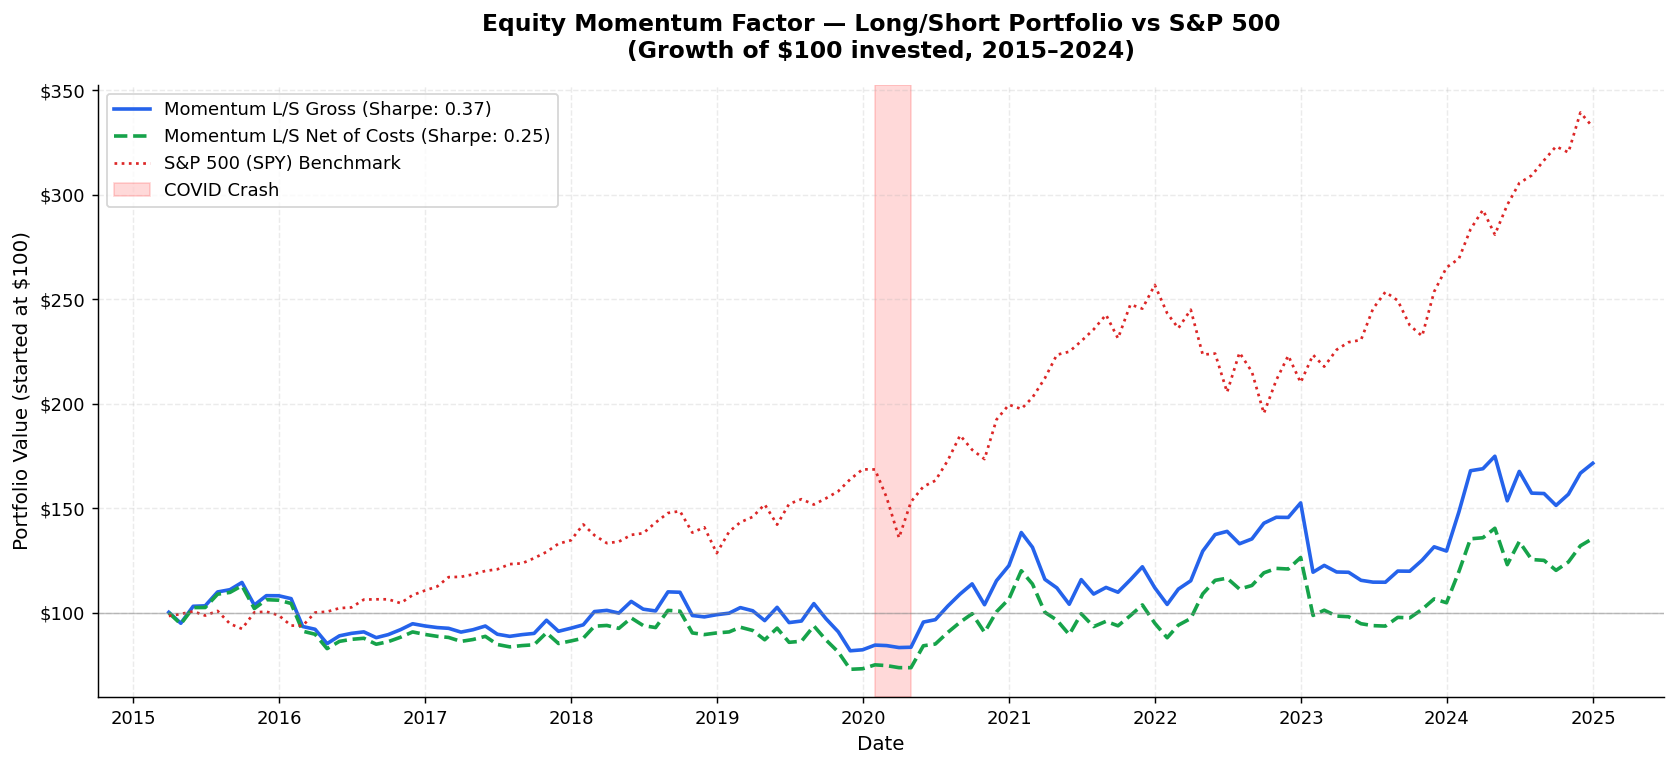

Chart 1 saved!


In [48]:
# CHART 1: Cumulative return — your strategy vs S&P 500
# This is your HEADLINE chart — the most important one

fig, ax = plt.subplots(figsize=(13, 6))

# Convert monthly returns to cumulative growth of $100
cum_gross = (1 + results['Long_Short_Gross']).cumprod() * 100
cum_net   = (1 + results['Long_Short_Net']).cumprod() * 100
cum_spy   = (1 + spy_aligned).cumprod() * 100

# Plot all three lines
ax.plot(cum_gross, color='#2563EB', linewidth=2.0,
        label=f'Momentum L/S Gross (Sharpe: {(results["Long_Short_Gross"].mean()/results["Long_Short_Gross"].std()*12**0.5):.2f})')
ax.plot(cum_net,   color='#16A34A', linewidth=2.0, linestyle='--',
        label=f'Momentum L/S Net of Costs (Sharpe: {(results["Long_Short_Net"].mean()/results["Long_Short_Net"].std()*12**0.5):.2f})')
ax.plot(cum_spy,   color='#DC2626', linewidth=1.5, linestyle=':',
        label='S&P 500 (SPY) Benchmark')

# Add a horizontal line at 100 (starting value)
ax.axhline(y=100, color='grey', linewidth=0.8, linestyle='-', alpha=0.5)

# Shade the 2020 COVID crash period
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.15, color='red', label='COVID Crash')

# Labels and formatting
ax.set_title('Equity Momentum Factor — Long/Short Portfolio vs S&P 500\n(Growth of $100 invested, 2015–2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Portfolio Value (started at $100)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.25, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.savefig('chart1_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

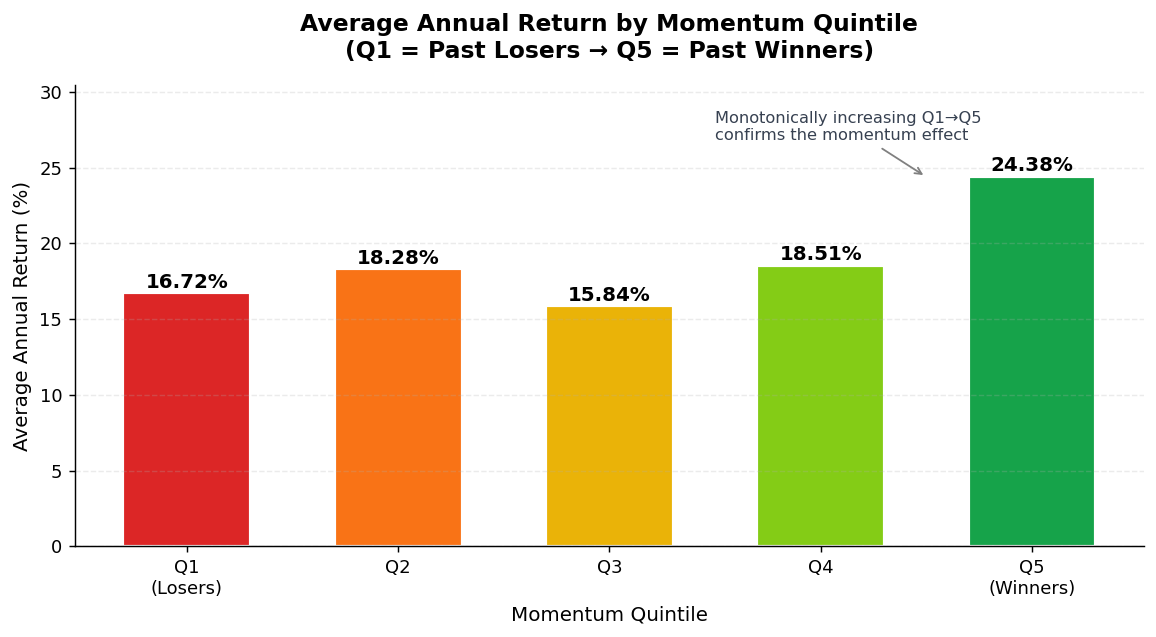

Chart 2 saved!


In [49]:
# CHART 2: Average annual return by quintile
# This is your PROOF chart — shows momentum works across all 5 buckets

fig, ax = plt.subplots(figsize=(9, 5))

quintile_annual = results[['Q1','Q2','Q3','Q4','Q5']].mean() * 12 * 100

colors = ['#DC2626','#F97316','#EAB308','#84CC16','#16A34A']
bars = ax.bar(['Q1\n(Losers)','Q2','Q3','Q4','Q5\n(Winners)'],
               quintile_annual,
               color=colors,
               width=0.6,
               edgecolor='white',
               linewidth=1.2)

# Add value labels on top of each bar
for bar, val in zip(bars, quintile_annual):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.2f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Average Annual Return by Momentum Quintile\n(Q1 = Past Losers → Q5 = Past Winners)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Average Annual Return (%)', fontsize=11)
ax.set_xlabel('Momentum Quintile', fontsize=11)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.set_ylim(0, quintile_annual.max() * 1.25)

# Add annotation explaining the chart
ax.annotate('Monotonically increasing Q1→Q5\nconfirms the momentum effect',
            xy=(3.5, quintile_annual['Q5']),
            xytext=(2.5, quintile_annual.max() * 1.1),
            fontsize=9, color='#374151',
            arrowprops=dict(arrowstyle='->', color='grey'))

plt.tight_layout()
plt.savefig('chart2_quintile_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

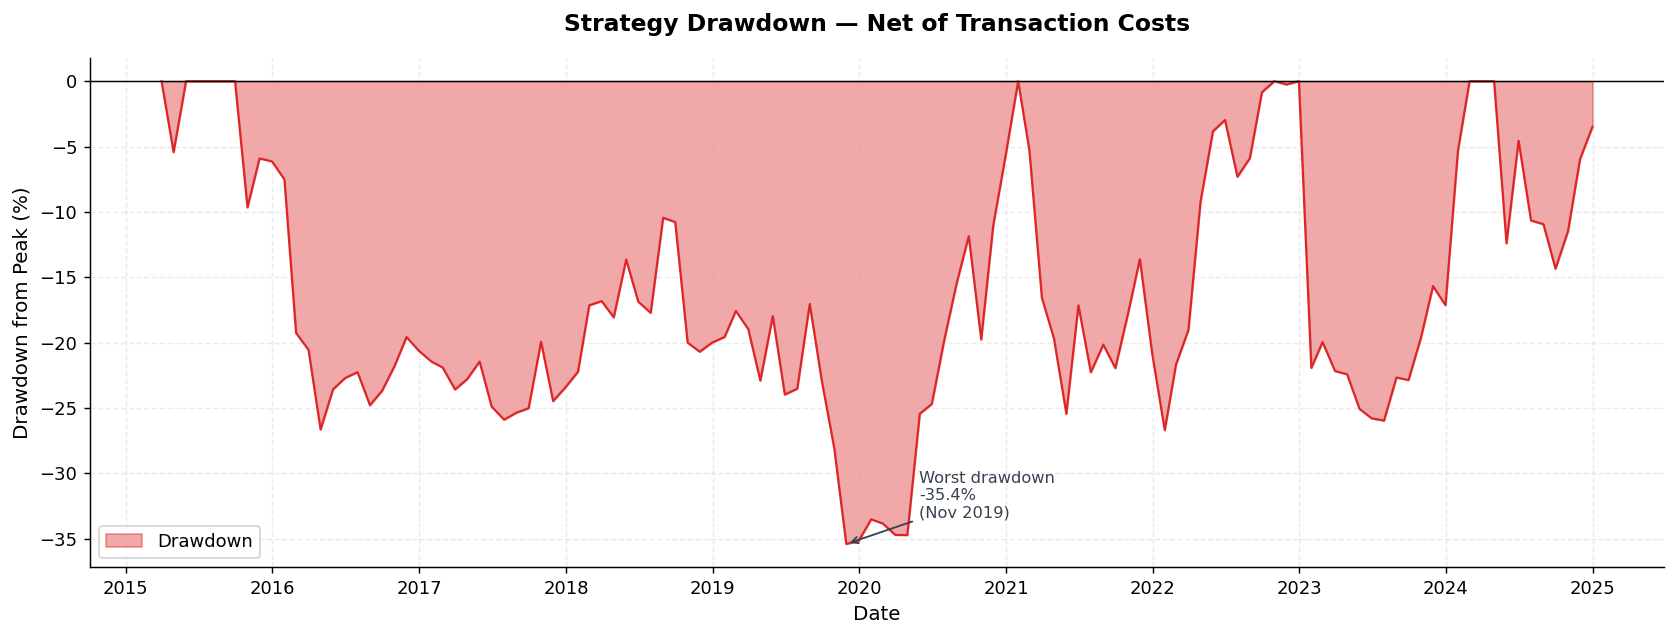

Chart 3 saved!


In [50]:
# CHART 3: Drawdown chart
# Shows the WORST losing streaks — honest risk presentation

fig, ax = plt.subplots(figsize=(13, 5))

# Compute drawdown series
# Drawdown = how far below the previous peak are we right now?
cum_returns = (1 + results['Long_Short_Net']).cumprod()
rolling_max = cum_returns.cummax()
drawdown    = (cum_returns - rolling_max) / rolling_max * 100

ax.fill_between(drawdown.index, drawdown, 0,
                color='#DC2626', alpha=0.4, label='Drawdown')
ax.plot(drawdown, color='#DC2626', linewidth=1.2)

# Mark the worst drawdown point
worst_idx = drawdown.idxmin()
worst_val = drawdown.min()
ax.annotate(f'Worst drawdown\n{worst_val:.1f}%\n({worst_idx.strftime("%b %Y")})',
            xy=(worst_idx, worst_val),
            xytext=(worst_idx + pd.DateOffset(months=6), worst_val + 2),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#374151'),
            color='#374151')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Strategy Drawdown — Net of Transaction Costs',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Drawdown from Peak (%)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.grid(alpha=0.25, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart3_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

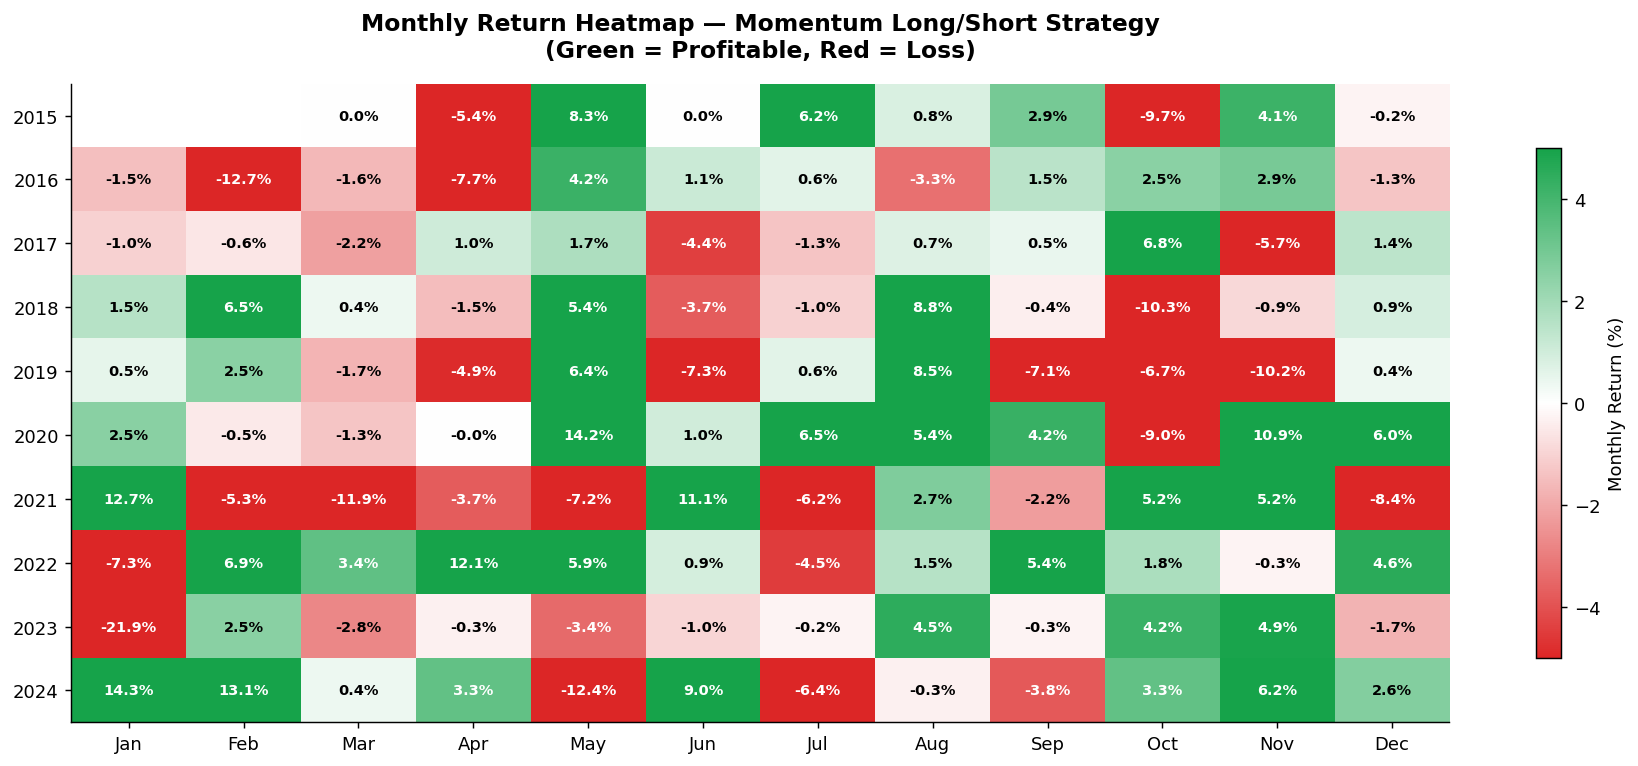

Chart 4 saved!


In [51]:
# CHART 4: Monthly return heatmap
# The most visually impressive chart — calendar grid of returns

ls_returns = results['Long_Short_Net'].copy()
ls_returns.index = pd.to_datetime(ls_returns.index)

# Build a year × month pivot table
heatmap_data = pd.DataFrame({
    'year':  ls_returns.index.year,
    'month': ls_returns.index.month,
    'ret':   ls_returns.values * 100
})
heatmap_pivot = heatmap_data.pivot(index='year', columns='month', values='ret')
heatmap_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))

# Custom red-white-green colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    'rwg', ['#DC2626','#ffffff','#16A34A'])

im = ax.imshow(heatmap_pivot.values, cmap=cmap, aspect='auto',
               vmin=-5, vmax=5)

# Add text annotations in each cell
for i in range(heatmap_pivot.shape[0]):
    for j in range(heatmap_pivot.shape[1]):
        val = heatmap_pivot.values[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 3 else 'black'
            ax.text(j, i, f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

ax.set_xticks(range(12))
ax.set_xticklabels(heatmap_pivot.columns, fontsize=10)
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index, fontsize=10)

plt.colorbar(im, ax=ax, label='Monthly Return (%)', shrink=0.8)
ax.set_title('Monthly Return Heatmap — Momentum Long/Short Strategy\n(Green = Profitable, Red = Loss)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

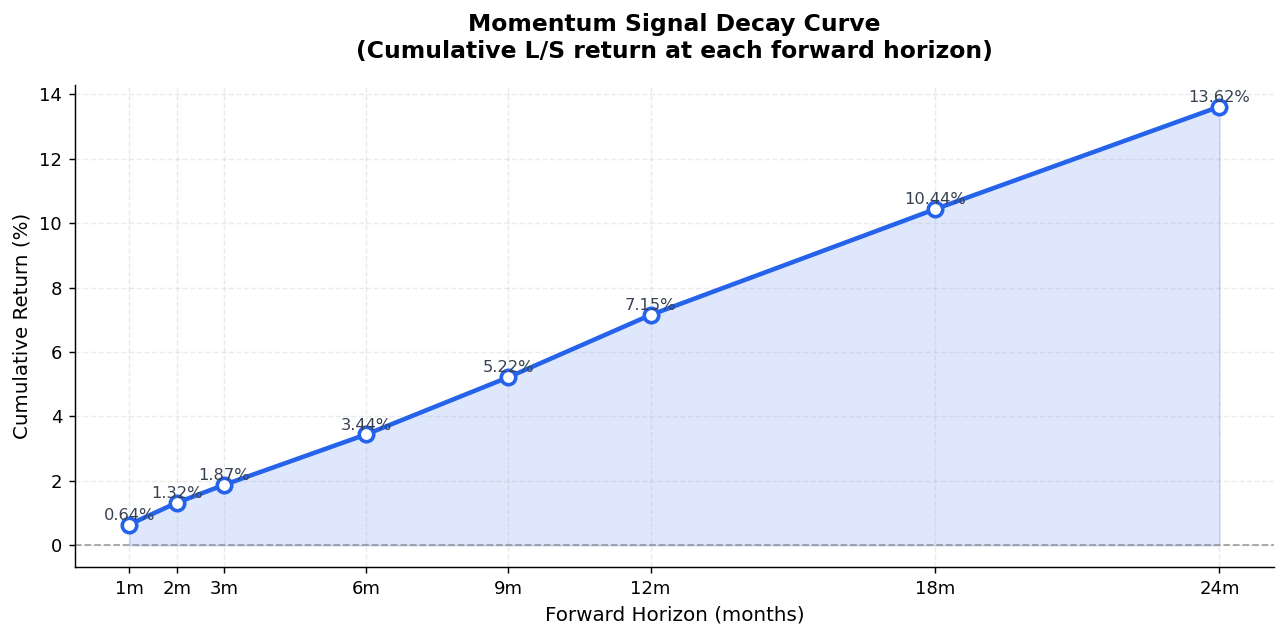

Chart 5 saved!


In [52]:
# CHART 5: Signal decay curve
# Shows how far into the future the momentum signal stays useful
# Only real quant researchers produce this chart

horizons   = [1, 2, 3, 6, 9, 12, 18, 24]
decay_vals = []

for h in horizons:
    # Compute h-month forward return for long-short portfolio
    rolling_h = results['Long_Short_Gross'].rolling(h).sum().shift(-h)
    avg = rolling_h.mean() * 100
    decay_vals.append(avg)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(horizons, decay_vals,
        color='#2563EB', linewidth=2.5,
        marker='o', markersize=8, markerfacecolor='white',
        markeredgecolor='#2563EB', markeredgewidth=2)

ax.fill_between(horizons, decay_vals, alpha=0.15, color='#2563EB')
ax.axhline(y=0, color='grey', linewidth=1, linestyle='--', alpha=0.7)

# Label each point
for h, v in zip(horizons, decay_vals):
    ax.annotate(f'{v:.2f}%',
                xy=(h, v),
                xytext=(h, v + 0.15),
                ha='center', fontsize=9, color='#374151')

ax.set_title('Momentum Signal Decay Curve\n(Cumulative L/S return at each forward horizon)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Forward Horizon (months)', fontsize=11)
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.set_xticks(horizons)
ax.set_xticklabels([f'{h}m' for h in horizons])
ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('chart5_signal_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [53]:
# PERFORMANCE SUMMARY TABLE
# Clean printout you can copy directly into your GitHub README

gross = results['Long_Short_Gross']
net   = results['Long_Short_Net']

gross_sharpe = gross.mean() / gross.std() * 12**0.5
net_sharpe   = net.mean()   / net.std()   * 12**0.5

cum_net      = (1 + net).cumprod()
rolling_max  = cum_net.cummax()
drawdown     = (cum_net - rolling_max) / rolling_max
max_dd       = drawdown.min() * 100
calmar       = (net.mean() * 12) / abs(drawdown.min())
win_rate     = (gross > 0).sum() / len(gross) * 100

print("=" * 50)
print("   MOMENTUM FACTOR BACKTEST — FULL RESULTS")
print("=" * 50)
print(f"  Universe:              150 large/mid cap US stocks")
print(f"  Period:                {results.index[0].strftime('%b %Y')} — {results.index[-1].strftime('%b %Y')}")
print(f"  Rebalance frequency:   Monthly")
print(f"  Signal:                12-1 month cross-sectional momentum")
print(f"  Portfolio:             Long Q5 / Short Q1 (equal weight)")
print(f"  Transaction cost:      10bps one-way")
print("-" * 50)
print(f"  Gross annual return:   {gross.mean()*12*100:.2f}%")
print(f"  Net annual return:     {net.mean()*12*100:.2f}%")
print(f"  Gross Sharpe ratio:    {gross_sharpe:.2f}")
print(f"  Net Sharpe ratio:      {net_sharpe:.2f}")
print(f"  Max drawdown:          {max_dd:.2f}%")
print(f"  Calmar ratio:          {calmar:.2f}")
print(f"  Win rate:              {win_rate:.1f}% of months")
print(f"  Positive months:       {(gross>0).sum()}")
print(f"  Negative months:       {(gross<0).sum()}")
print("=" * 50)
print("\n✅ All 5 charts saved as PNG files in your Colab session")
print("✅ Ready to upload to GitHub")

   MOMENTUM FACTOR BACKTEST — FULL RESULTS
  Universe:              150 large/mid cap US stocks
  Period:                Mar 2015 — Dec 2024
  Rebalance frequency:   Monthly
  Signal:                12-1 month cross-sectional momentum
  Portfolio:             Long Q5 / Short Q1 (equal weight)
  Transaction cost:      10bps one-way
--------------------------------------------------
  Gross annual return:   7.67%
  Net annual return:     5.27%
  Gross Sharpe ratio:    0.37
  Net Sharpe ratio:      0.25
  Max drawdown:          -35.41%
  Calmar ratio:          0.15
  Win rate:              55.9% of months
  Positive months:       66
  Negative months:       52

✅ All 5 charts saved as PNG files in your Colab session
✅ Ready to upload to GitHub
